Instrument Classification and Robustness Analysis Topic Research

In [1]:
import librosa
import numpy

In [2]:
#Data Path
data_home = "./mirdata/IRMAS-TrainingData"
y_audio_path = "./mirdata/IRMAS-TrainingData/cel/[cel][cla]0001__1.wav"

#load and test data
y, sr = librosa.load(y_audio_path,sr=44100)
#Audio sample in 44.1khz
print(y.shape, sr)



(132299,) 44100


C:\Users\LionsInTheSky\AppData\Local\Temp\ipykernel_12388\3082606560.py:5: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)


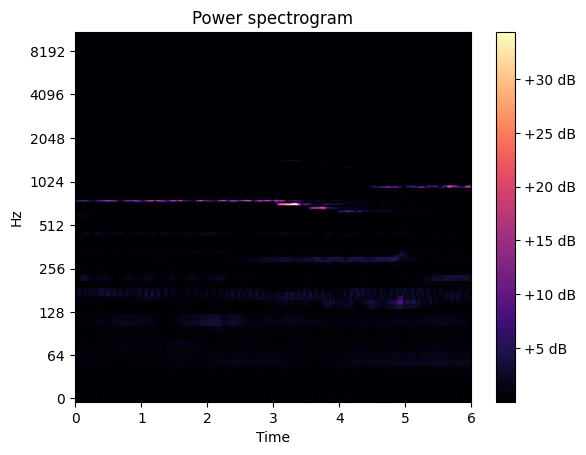

In [3]:
import matplotlib.pyplot as plt 
#audio spectrogram
Y = librosa.stft(y)
fig, ax = plt.subplots()
img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")




In [4]:
from dataset_preprocessing import create_dataset_csv
class_label = {'cel':0, 'pia':1, 'sax':2, 'flu':3, 'vio':4}

#load all data
df = create_dataset_csv(data_home)
#filter data by class label, only 5 classes are used in this project
df_filtered = df[df['label'].isin(class_label.keys())].copy()
df_filtered['label_id'] = df_filtered['label'].map(class_label)

print(df_filtered['label'].value_counts())

label
pia    721
sax    626
vio    580
flu    451
cel    364
Name: count, dtype: int64


In [5]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
df_filtered.to_csv(save_path, index=False, encoding='utf-8')

print("Filtered dataset saved to:", save_path)

Filtered dataset saved to: ./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv


In [ ]:
#read the saved csv file to verify
df_dataset = pd.read_csv(save_path)
print(df_dataset.head())


                                           file_path label  label_id
0  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
1  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
2  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
3  ./mirdata/IRMAS-TrainingData\cel\041__[cel][no...   cel         0
4  ./mirdata/IRMAS-TrainingData\cel\041__[cel][no...   cel         0


In [17]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df_dataset, test_size=0.2)
print("Training set size:", len(train_df))
print("Testing set size:", len(test_df))
print("Train set",train_df.head())

Training set size: 2193
Testing set size: 549
Train set                                               file_path label  label_id
387   ./mirdata/IRMAS-TrainingData\flu\051__[flu][no...   flu         3
1848  ./mirdata/IRMAS-TrainingData\sax\[sax][jaz_blu...   sax         2
1826  ./mirdata/IRMAS-TrainingData\sax\[sax][cla]175...   sax         2
1245  ./mirdata/IRMAS-TrainingData\pia\[pia][jaz_blu...   pia         1
2318  ./mirdata/IRMAS-TrainingData\vio\155__[vio][no...   vio         4


In [ ]:
train_label = train_df['label_id'].values
test_label = test_df['label_id'].values
train_set = train_df['file_path'].values
test_set = test_df['file_path'].values

assert len(train_label) == len(train_set)
assert len(test_label) == len(test_set)

array(['./mirdata/IRMAS-TrainingData\\flu\\051__[flu][nod][cou_fol]0413__1.wav',
       './mirdata/IRMAS-TrainingData\\sax\\[sax][jaz_blu]1581__1.wav',
       './mirdata/IRMAS-TrainingData\\sax\\[sax][cla]1753__3.wav', ...,
       './mirdata/IRMAS-TrainingData\\pia\\[pia][jaz_blu]1452__2.wav',
       './mirdata/IRMAS-TrainingData\\pia\\[pia][jaz_blu]1481__2.wav',
       './mirdata/IRMAS-TrainingData\\pia\\[pia][pop_roc]1536__3.wav'],
      shape=(2193,), dtype=object)